In [9]:
import numpy as np
print(np.__version__)
print(np.__file__)
print(hasattr(np, "trapz"))
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÁMETROS DEL MODELO (RAMPA)
# ==========================================
alpha = 0.5    # Pendiente de la rampa (qué tan fuerte llueve al subir q)
E_star = 0.2   # Tasa de recarga (evaporación)
D0_sq = 0.05   # Difusión (ruido)
qc = 1.0       # Umbral de lluvia

# Parámetros de simulación
dt = 0.01    
N_sim = 15000  
t_max = 20.0

2.4.3
c:\Users\elxpa\Documents\GitHub\TESIS\.venv\Lib\site-packages\numpy\__init__.py
False


In [10]:
def pdf_analitica_rampa(t):
    """
    Solución analítica exacta para periodos secos (FPT Gaussiana Inversa)
    obtenida al hacer tender el término de rampa (alpha) a 0.
    """
    # Parámetros físicos de tu simulación
    b = 1.0 - 0.5           # Distancia desde el inicio (0.5) hasta qc (1.0)
    mu = E_star             # Deriva constante (0.2)
    sigma_sq = 2 * D0_sq    # Varianza (0.1)
    
    # Prevenir divisiones por cero
    t = np.where(t <= 0, 1e-10, t)
    
    # Términos de la Gaussiana Inversa
    termino1 = b / np.sqrt(2 * np.pi * sigma_sq * t**3)
    termino2 = np.exp(-((b - mu * t)**2) / (2 * sigma_sq * t))
    
    pdf = termino1 * termino2
    return pdf

t_teo = np.linspace(0.01, t_max, 500)
pdf_teo = pdf_analitica_rampa(t_teo)

In [11]:
def simular_rampa(constrained=False):
    q = np.ones(N_sim) * 0.5  # Empezamos abajo del umbral
    durations = []
    
    # Para simplificar, mediremos la duración de los periodos SECOS 
    # (tiempo que tarda en llegar de 0.5 a qc=1.0)
    active = np.ones(N_sim, dtype=bool)
    results = np.zeros(N_sim)
    
    sigma = np.sqrt(2 * D0_sq)
    t = 0.0
    
    while np.any(active) and t < t_max:
        t += dt
        n_active = np.sum(active)
        dW = np.random.normal(0, np.sqrt(dt), size=n_active)
        
        # Durante el dry spell, P = 0, así que la ecuación es la misma
        q[active] += E_star * dt + sigma * dW
        
        if constrained:
            q[active] = np.maximum(0, q[active]) # Método Clip en 0
            
        crossed = q[active] >= qc
        if np.any(crossed):
            idx = np.where(active)[0][crossed]
            results[idx] = t
            active[idx] = False
            
    return results[results > 0]

# Ejecución
dur_libre = simular_rampa(constrained=False)
dur_clip = simular_rampa(constrained=True)

Área bajo histograma libre: 1.0000


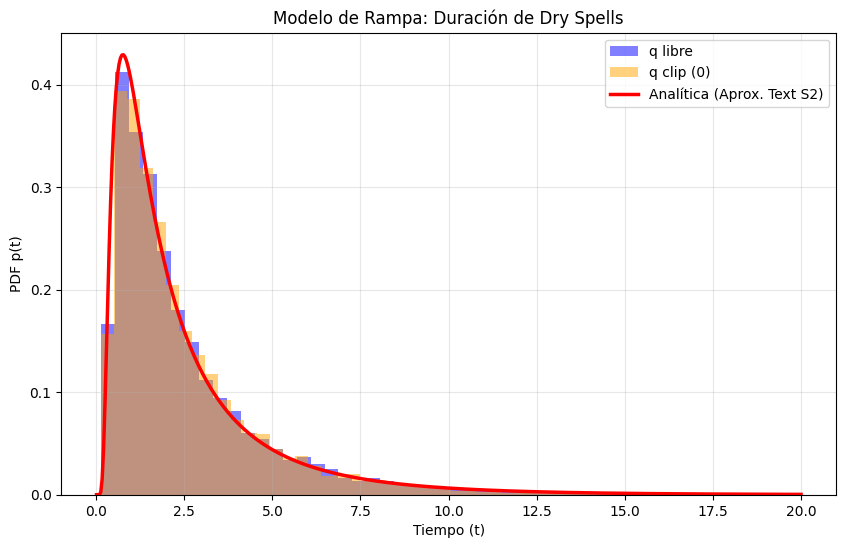

In [12]:
plt.figure(figsize=(10, 6))

# Histograma normalizado (density=True para que integre a 1)
count_libre, bins_libre, _ = plt.hist(dur_libre, bins=50, density=True, 
                                     alpha=0.5, color='blue', label='q libre')
count_clip, bins_clip, _ = plt.hist(dur_clip, bins=50, density=True, 
                                   alpha=0.5, color='orange', label='q clip (0)')

# Chequeo de normalización (lo que pidió el profe)
area_libre = np.sum(np.diff(bins_libre) * count_libre)
print(f"Área bajo histograma libre: {area_libre:.4f}")

plt.plot(t_teo, pdf_teo, 'r-', lw=2.5, label='Analítica (Aprox. Text S2)')
plt.title('Modelo de Rampa: Duración de Dry Spells')
plt.xlabel('Tiempo (t)')
plt.ylabel('PDF p(t)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Método en el que clip si generaría una diferencia crítica en el histograma

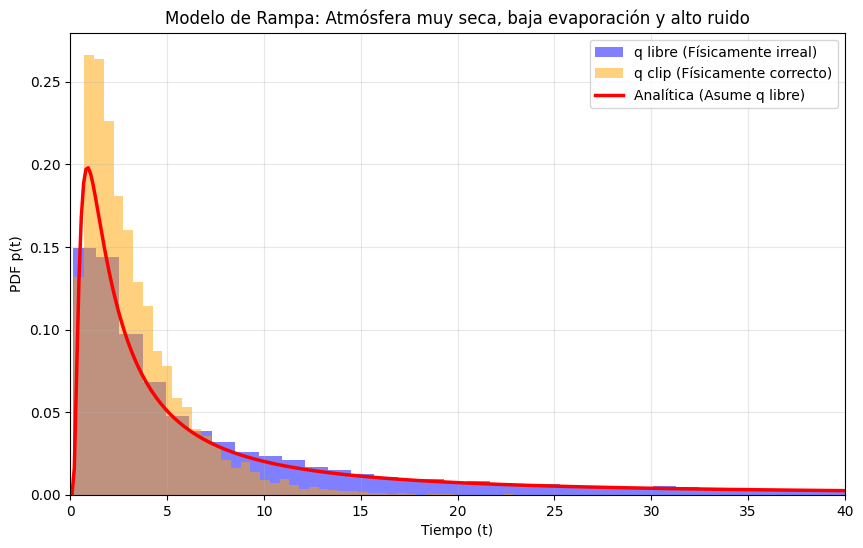

In [14]:
# ==========================================
# 2. ESCENARIO DE ALTA VARIABILIDAD Y BAJA EVAPORACIÓN
# ==========================================
E_star_alt = 0.05   # Evaporación muy débil
D0_sq_alt = 0.15    # Mucho ruido (turbulencia)
q_init = 0.1        # Empezamos con la atmósfera muy seca
qc = 1.0

def simular_rampa_extrema(constrained=False):
    q = np.ones(N_sim) * q_init 
    active = np.ones(N_sim, dtype=bool)
    results = np.zeros(N_sim)
    sigma = np.sqrt(2 * D0_sq_alt)
    t = 0.0
    
    while np.any(active) and t < t_max * 3: # Damos más tiempo máximo porque tardará más
        t += dt
        n_active = np.sum(active)
        dW = np.random.normal(0, np.sqrt(dt), size=n_active)
        
        q[active] += E_star_alt * dt + sigma * dW
        
        if constrained:
            q[active] = np.maximum(0, q[active]) # Método Clip en 0
            
        crossed = q[active] >= qc
        if np.any(crossed):
            idx = np.where(active)[0][crossed]
            results[idx] = t
            active[idx] = False
            
    return results[results > 0]

# Simulamos
dur_libre_ext = simular_rampa_extrema(constrained=False)
dur_clip_ext = simular_rampa_extrema(constrained=True)

# Nueva curva teórica (sigue asumiendo q libre para contrastar)
def pdf_analitica_extrema(t):
    b = qc - q_init
    mu = E_star_alt
    sigma_sq = 2 * D0_sq_alt
    t = np.where(t <= 0, 1e-10, t)
    return (b / np.sqrt(2 * np.pi * sigma_sq * t**3)) * np.exp(-((b - mu * t)**2) / (2 * sigma_sq * t))

t_teo_ext = np.linspace(0.1, t_max * 3, 500)
pdf_teo_ext = pdf_analitica_extrema(t_teo_ext)

# Graficamos
plt.figure(figsize=(10, 6))
plt.hist(dur_libre_ext, bins=50, density=True, alpha=0.5, color='blue', label='q libre (Físicamente irreal)')
plt.hist(dur_clip_ext, bins=50, density=True, alpha=0.5, color='orange', label='q clip (Físicamente correcto)')
plt.plot(t_teo_ext, pdf_teo_ext, 'r-', lw=2.5, label='Analítica (Asume q libre)')
plt.title('Modelo de Rampa: Atmósfera muy seca, baja evaporación y alto ruido')
plt.xlabel('Tiempo (t)')
plt.ylabel('PDF p(t)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 40)
plt.show()